In [1]:
import numpy as np
import torch
import os
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm, trange

from sklearn.model_selection import train_test_split

In [5]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
!wget -q -nc -O facial_keypoints.npz "https://www.dropbox.com/scl/fi/27qggijmythfjg04s24xq/facial_keypoints.npz?rlkey=h91gwodhrfuz8hrc7ux9qnq7s&dl=1"

In [7]:
data = np.load('facial_keypoints.npz')
images = data['images']
keypoints = data['keypoints']

In [8]:
def masked_mae_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """ Compute masked mean absolute error (MAE) loss, ignoring NaN values.
        This function returns the numerator and denominator separately;
        the loss is calculated as num/den.

        To calculate the average loss over batches, you should
        separately sum the numerators and demoninators,
        and then divide: total_num / total_den.

        Arguments:
            y_pred: predicted keypoints [B,C]
            y_true: ground truth keypoints (may contain NaNs) [B,C]

        Returns:
            numerator, denominator of MAE
    """
    mask = 1-torch.isnan(y_true).float()
    diff = torch.abs(y_true-y_pred)
    return torch.nansum(diff*mask), torch.nansum(mask)

##Data Inspection

In [11]:
print("Images:")
print("Shape:", images.shape)
print("Dtype:", images.dtype)
print("Min:", np.min(images))
print("Max:", np.max(images))


Images:
Shape: (7049, 1, 96, 96)
Dtype: int64
Min: 0
Max: 255


In [13]:
print("keypoints:")
print("Shape:", keypoints.shape)
print("Dtype", keypoints.dtype)
print("Min:", np.nanmin(keypoints))
print("Max:", np.nanmax(keypoints))

keypoints:
Shape: (7049, 30)
Dtype float32
Min: 0.686592
Max: 95.935646


TypeError: Invalid shape (1, 96, 96) for image data

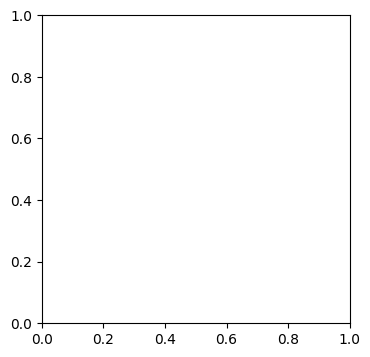

In [17]:
for i in range(5):
  plt.figure(figsize = (4, 4))
  plt.imshow(images[i], cmap = "viridis")
  points = keypoints[i].reshape(15, 2)

  plt.scatter(
      points[:, 0],
      points[:, 1],
      s = 20
  )

  plt.title(f"Image {i}")
  plt.axis("off")
  plt.show()

##Preprocess and split the data

In [20]:
X = images / 255
y = keypoints / 96

X = X[:, None, :, :]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = .1,
    random_state = 12
)

##Prepare Dataset and DataLoader objects

In [22]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

/tmp/ipykernel_713/1552273445.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype = torch.float32)
/tmp/ipykernel_713/1552273445.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype = torch.float32)
/tmp/ipykernel_713/1552273445.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype = torch.float32)
/tmp/ipykernel_713/1552273445.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone(